In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_customers = pd.read_csv('olist_customers_dataset.csv') 
#  таблица с уникальными идентификаторами пользователей
df_items = pd.read_csv('olist_order_items_dataset.csv') 
#  товарные позиции, входящие в заказы
df_orders = pd.read_csv('olist_orders_dataset.csv') 
#  таблица заказов

In [3]:
df_customers.head(10)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG


In [4]:
df_items.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40


In [5]:
df_orders.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00


In [6]:
df_customers.shape

(99441, 5)

Далее рассмотрим количество уникальных значений по каждой переменной в трех датасетах, а также проверим их на наличие пропусков.

In [7]:
df_customers.nunique() 

customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

Видим, что один пользователь мог сделать несколько заказов.

In [8]:
df_customers.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [9]:
df_items.nunique()

order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64

In [10]:
df_items.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [11]:
df_orders.nunique()

order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
dtype: int64

In [12]:
df_orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

На этапе когортного анализа мы не используем те переменные, где были найдены пропуски, но на других этапах анализа это понимание пригодится.

Посмотрим, как распределены клиенты по городам и штатам.

In [13]:
df_customers.customer_city.value_counts(normalize=True).to_frame()

,customer_city
sao paulo,0.156274
rio de janeiro,0.069207
belo horizonte,0.027886
brasilia,0.021430
curitiba,0.015296
...,...
marques de souza,0.000010
general maynard,0.000010
cerrito,0.000010
mocajuba,0.000010


In [14]:
df_customers.customer_state.value_counts(normalize=True).to_frame()

,customer_state
SP,0.419807
RJ,0.129242
MG,0.117004
RS,0.054967
PR,0.050734
SC,0.036574
BA,0.033990
DF,0.021520
ES,0.020444
GO,0.020314


Из двух таблиц явно заметно, что больше 40% наших клиентов из штата Сан-Пауло (15% из города Сан Пауло). Другие два крупных штата - Рио-де-Жанейро (12,9%), Минас-Жерайс (11,7%).

## Задача 1. Оценить месячный retention в оформление заказа с помощью когортного анализа.

In [15]:
df = pd.merge(df_customers, df_orders, on='customer_id', how='inner')

In [16]:
df.dtypes

customer_id                      object
customer_unique_id               object
customer_zip_code_prefix          int64
customer_city                    object
customer_state                   object
order_id                         object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [17]:
df.customer_city

0                       franca
1        sao bernardo do campo
2                    sao paulo
3              mogi das cruzes
4                     campinas
                 ...          
99436                sao paulo
99437          taboao da serra
99438                fortaleza
99439                   canoas
99440                    cotia
Name: customer_city, Length: 99441, dtype: object

Для определения когорт берем время, когда клиент сделал заказ - колонку order_purchase_timestamp.

In [18]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

Сразу преобразуем в Timestamp другие даты для следующих этапов анализа.

In [19]:
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

In [20]:
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

In [21]:
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'])

In [22]:
dff = df.copy() 

In [23]:
# Извлекаем месяц и день заказа
dff['order_month'] = dff['order_purchase_timestamp'].dt.to_period('M')
dff['order_period_day'] = dff['order_purchase_timestamp'].dt.to_period('D')

In [24]:
dff.head(10)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,order_period_day
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,2017-05,2017-05-16
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,2018-01,2018-01-12
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,2018-05,2018-05-19
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,2018-03,2018-03-13
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,2018-07,2018-07-29
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC,5741ea1f91b5fbab2bd2dc653a5b5099,delivered,2017-09-14 18:14:31,2017-09-14 18:25:11,2017-09-18 21:27:40,2017-09-28 17:32:43,2017-10-04,2017-09,2017-09-14
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP,36e694cf4cbc2a4803200c35e84abdc4,delivered,2018-02-19 14:38:35,2018-02-19 14:50:37,2018-02-20 00:03:39,2018-02-20 16:25:51,2018-03-05,2018-02,2018-02-19
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG,1093c8304c7a003280dd34598194913d,delivered,2017-11-16 19:29:02,2017-11-16 19:55:41,2017-11-22 16:46:33,2017-11-27 12:44:36,2017-12-08,2017-11,2017-11-16
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR,1ebeea841c590e86a14a0d7a48e7d062,delivered,2018-01-18 12:35:44,2018-01-18 12:56:32,2018-01-18 23:25:35,2018-01-26 15:17:57,2018-02-20,2018-01,2018-01-18
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG,7433cbcc783205509d66a5260da5b574,delivered,2018-01-08 11:22:34,2018-01-08 11:35:27,2018-01-11 01:00:40,2018-01-13 14:51:55,2018-02-05,2018-01,2018-01-08


In [25]:
# Присваиваем когорты на основе даты первого заказа пользователя
dff['cohort'] = dff.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
dff['cohort_day'] = dff.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('D')

In [26]:
dff

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,order_period_day,cohort,cohort_day
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,2017-05,2017-05-16,2017-05,2017-05-16
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,2018-01,2018-01-12,2018-01,2018-01-12
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,2018-05,2018-05-19,2018-05,2018-05-19
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,2018-03,2018-03-13,2018-03,2018-03-13
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,2018-07,2018-07-29,2018-07,2018-07-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25,2018-04,2018-04-07,2018-04,2018-04-07
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20,2018-04,2018-04-04,2018-04,2018-04-04
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02,2018-04,2018-04-08,2018-04,2018-04-08
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05,2017-11,2017-11-03,2017-11,2017-11-03


In [27]:
from operator import attrgetter

In [28]:
# Рассчитываем номер периода в днях (месячные периоды, деля на 30)
dff['period_number_month'] = np.floor((dff.order_period_day - dff.cohort_day).apply(attrgetter('n')) / 30)

In [29]:
dff.order_status.value_counts() 
# посмотрим на количество заказов в зависимости от статуса

delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: order_status, dtype: int64

Сделаем фильтрацию только по доставленным заказам, чтобы по ним посмотреть когорты клиентов, так как если клиент получил заказ и вернулся, значит он доволен услугами нашего маркетплейса. Если они заказ не получили, оценить его, соответственно, он не смог. 

И честно говоря, если рассматривать по всем статусам заказов, исходя из предположения, что смотрим именно retention в оформление заказа (фактически, даже те заказы, которые не пришли, были оформлены), то retention остается на том же уровне, изменяется на несколько сотых процента.

In [30]:
dff_copy = dff.query("order_status == 'delivered'") 
# вид заказа, который буду рассматривать, - доставленные заказы

In [31]:
# Агрегируем данные по когортам и рассчитанному номеру периода (в месяцах)
dff_cohort = dff_copy.groupby(['cohort', 'period_number_month'])\
    .agg(n_customers=('customer_unique_id', 'nunique')).reset_index()

In [32]:
df_cohort = dff_cohort[dff_cohort.n_customers > 1] 

# не рассматриваем когортцы, где только 1 клиент
# выводов о retention сделать в таком случае будет невозможно

In [33]:
# Создаем сводную таблицу для когортного анализа
cohort_pivot = df_cohort.pivot_table(index='cohort', columns='period_number_month', values='n_customers')

In [34]:
cohort_pivot

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0
cohort,,,,,,,,,,,,,,,,,,,
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
2017-01,718.0,2.0,NaN,4.0,NaN,NaN,2.0,2.0,NaN,NaN,4.0,4.0,3.0,2.0,NaN,2.0,2.0,2.0,NaN
2017-02,1627.0,3.0,3.0,6.0,4.0,2.0,4.0,2.0,2.0,5.0,NaN,6.0,2.0,3.0,2.0,NaN,2.0,4.0,NaN
2017-03,2504.0,7.0,13.0,11.0,3.0,2.0,9.0,4.0,7.0,6.0,5.0,4.0,5.0,3.0,7.0,2.0,3.0,3.0,NaN
2017-04,2254.0,8.0,6.0,NaN,7.0,8.0,6.0,10.0,5.0,6.0,2.0,4.0,NaN,2.0,2.0,2.0,4.0,NaN,NaN
2017-05,3452.0,16.0,15.0,11.0,13.0,12.0,12.0,5.0,10.0,9.0,8.0,11.0,7.0,4.0,9.0,5.0,NaN,NaN,NaN
2017-06,3035.0,13.0,14.0,11.0,4.0,15.0,10.0,6.0,4.0,11.0,7.0,8.0,2.0,8.0,3.0,NaN,NaN,NaN,NaN
2017-07,3750.0,15.0,10.0,10.0,12.0,7.0,10.0,7.0,5.0,11.0,9.0,9.0,6.0,7.0,NaN,NaN,NaN,NaN,NaN
2017-08,4055.0,27.0,10.0,14.0,15.0,19.0,10.0,10.0,6.0,7.0,9.0,6.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# Рассчитываем размеры когорт (первый столбец сводной таблицы)
cohort_size = cohort_pivot.iloc[:, 0]

In [36]:
cohort_size

cohort
2016-10     262.0
2017-01     718.0
2017-02    1627.0
2017-03    2504.0
2017-04    2254.0
2017-05    3452.0
2017-06    3035.0
2017-07    3750.0
2017-08    4055.0
2017-09    4002.0
2017-10    4326.0
2017-11    7058.0
2017-12    5336.0
2018-01    6838.0
2018-02    6287.0
2018-03    6770.0
2018-04    6575.0
2018-05    6503.0
2018-06    5874.0
2018-07    5944.0
2018-08    6138.0
Freq: M, Name: 0.0, dtype: float64

In [37]:
# Вычисляем коэффициенты удержания, разделяем на размер когорты
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

In [38]:
retention_matrix.head(15)

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0
cohort,,,,,,,,,,,,,,,,,,,
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007634
2017-01,1.0,0.002786,NaN,0.005571,NaN,NaN,0.002786,0.002786,NaN,NaN,0.005571,0.005571,0.004178,0.002786,NaN,0.002786,0.002786,0.002786,NaN
2017-02,1.0,0.001844,0.001844,0.003688,0.002459,0.001229,0.002459,0.001229,0.001229,0.003073,NaN,0.003688,0.001229,0.001844,0.001229,NaN,0.001229,0.002459,NaN
2017-03,1.0,0.002796,0.005192,0.004393,0.001198,0.000799,0.003594,0.001597,0.002796,0.002396,0.001997,0.001597,0.001997,0.001198,0.002796,0.000799,0.001198,0.001198,NaN
2017-04,1.0,0.003549,0.002662,NaN,0.003106,0.003549,0.002662,0.004437,0.002218,0.002662,0.000887,0.001775,NaN,0.000887,0.000887,0.000887,0.001775,NaN,NaN
2017-05,1.0,0.004635,0.004345,0.003187,0.003766,0.003476,0.003476,0.001448,0.002897,0.002607,0.002317,0.003187,0.002028,0.001159,0.002607,0.001448,NaN,NaN,NaN
2017-06,1.0,0.004283,0.004613,0.003624,0.001318,0.004942,0.003295,0.001977,0.001318,0.003624,0.002306,0.002636,0.000659,0.002636,0.000988,NaN,NaN,NaN,NaN
2017-07,1.0,0.004000,0.002667,0.002667,0.003200,0.001867,0.002667,0.001867,0.001333,0.002933,0.002400,0.002400,0.001600,0.001867,NaN,NaN,NaN,NaN,NaN
2017-08,1.0,0.006658,0.002466,0.003453,0.003699,0.004686,0.002466,0.002466,0.001480,0.001726,0.002219,0.001480,0.000740,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
from matplotlib import colors as mcolors

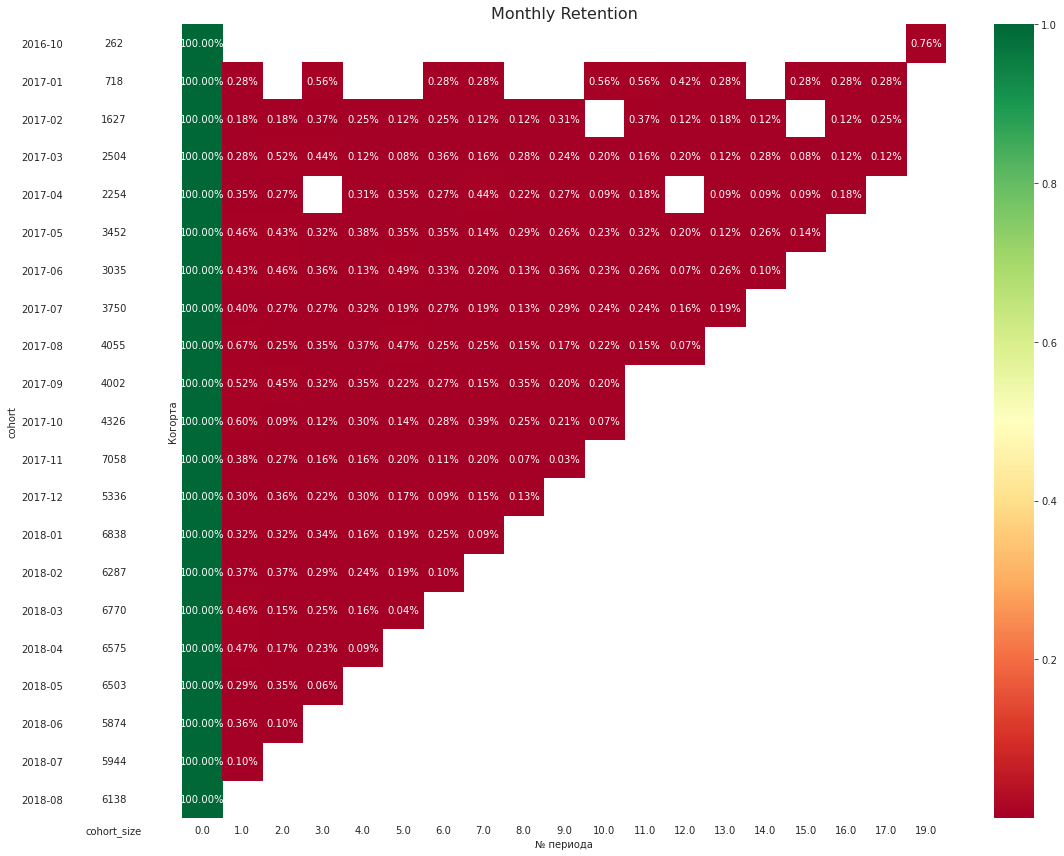

In [40]:
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Тепловая карта для коэффициентов удержания
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.2%',
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

Из когортного анализа можно сделать вывод, что возвращаемость клиента в продукт каждый месяц очень низкая по всем когортам.

1. Проанализируем, чему равен медианный retention 1-го месяца для всех когорт.

In [41]:
print(f'Медианный retention 1-го месяца для всех когорт составляет {retention_matrix[1].median() * 100:.4f}%.')

Медианный retention 1-го месяца для всех когорт составляет 0.3658%.


2. Найдем когорту с самым высоким retention на 3-й месяц.

In [42]:
print(f'Самый высокий retention 3-го месяца у когорты {retention_matrix[3].idxmax()}.')
print(f'Значение коэффициента удержания составило {retention_matrix[3].max() * 100:.4f}%.') 

Самый высокий retention 3-го месяца у когорты 2017-01.
Значение коэффициента удержания составило 0.5571%.


Итог когортного анализа:

- Наблюдается очень низкий retention по всем когортам
- Медианный retention 1-го месяца для всех когорт составляет 0.3658%.
- Самый высокий retention 3-го месяца у когорты 2017-01, значение составило 0.5571%.

## Задача 2. Определить, существует ли product/market fit у маркетплейса.

Рассмотрим два вида retention (N-Day Retention и Rolling Retention) и построим кривую retention, чтобы сделать последующие выводы о наличии или отсутствии product/market fit у маркетплейса.

In [43]:
median_retention = retention_matrix.mean().to_frame().reset_index() 
# рассчитаем медианные значения retention всех когорт по каждому месяцу 
# берем медианные значения, так как медиана менее чувствительна к смещениям в распределении данных

In [44]:
median_retention = median_retention.rename(columns={0: 'median_retention'})

In [45]:
median_retention

,period_number_month,median_retention
0,0.0,1.000000
1,1.0,0.003806
2,2.0,0.002944
3,3.0,0.002902
4,4.0,0.002422
5,5.0,0.002293
6,6.0,0.002460
7,7.0,0.002123
8,8.0,0.001939
9,9.0,0.002339


Text(0.5, 1.0, 'N-Day Retention curve')

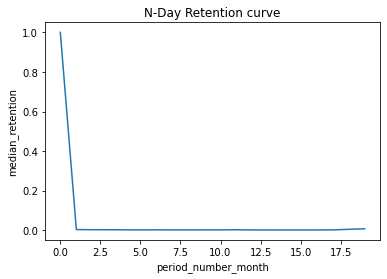

In [46]:
sns.lineplot(data=median_retention, x='period_number_month', y='median_retention')
plt.title('N-Day Retention curve')

In [47]:
median_retention['rolling_3'] = median_retention['median_retention'].rolling(3, min_periods=1).mean()

Text(0.5, 1.0, 'Rolling Retention curve')

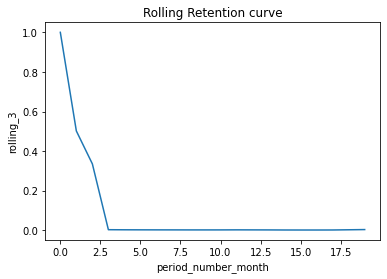

In [48]:
sns.lineplot(data=median_retention, x='period_number_month', y='rolling_3') 
# окно в 3 месяца
plt.title('Rolling Retention curve')

In [49]:
median_retention['rolling_4'] = median_retention['median_retention'].rolling(4, min_periods=1).mean()

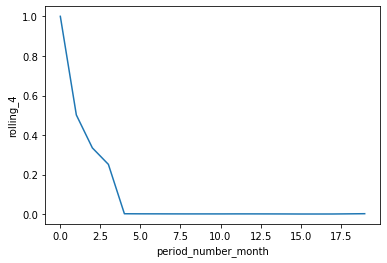

In [50]:
sns.lineplot(data=median_retention, x='period_number_month', y='rolling_4') 
# окно в 4 месяца

Поэспериментировали с разными окнами для rolling retention, построили кривую для классического retention, но по всем графикам видно, что доля клиентов, которые возвращаются к заказам, низкая. Заметно резкое падение после создания продукта. Значения стабилизировались, но на очень низком уровне (приближенно к 0%). 

Продукт не очень хорошо закрывает потребности клиента -> PMF отсутствует и к масштабированию пока не готов. Необходимо понять и решить проблему в продукте, прежде чем привлекать новых клиентов, которых не получается удержат в продукте.

### Возможные причины отстутствия product/market fit

1. Сравним обещанную дату доставки заказа (order_estimated_delivery_date) и фактическую дату доставки (order_delivered_customer_date). Выясним, есть ли задержки по доставке заказов и насколько это частое явление.

In [51]:
delays = dff[['order_estimated_delivery_date', 'order_delivered_customer_date']] 
# по всем статусам заказов

In [52]:
delays_copy = delays.copy()

In [53]:
# переводим в формат даты, так как время доставки для выявления задержек в доставке не нужно
delays_copy["order_delivered_customer_date"] = delays_copy["order_delivered_customer_date"].dt.date 

In [54]:
delays_copy["order_delivered_customer_date"] = pd.to_datetime(delays_copy["order_delivered_customer_date"])

In [55]:
delays_copy['delay'] = delays_copy.order_delivered_customer_date - delays_copy.order_estimated_delivery_date

# если значение в колонке больше 0, то задержка в доставке была

In [56]:
delays_copy

,order_estimated_delivery_date,order_delivered_customer_date,delay
0,2017-06-05,2017-05-25,-11 days
1,2018-02-06,2018-01-29,-8 days
2,2018-06-13,2018-06-14,1 days
3,2018-04-10,2018-03-28,-13 days
4,2018-08-15,2018-08-09,-6 days
...,...,...,...
99436,2018-04-25,2018-04-13,-12 days
99437,2018-04-20,2018-04-11,-9 days
99438,2018-05-02,2018-05-09,7 days
99439,2017-12-05,2017-11-16,-19 days


In [57]:
delays_copy['days_of_delay'] = delays_copy['delay'].dt.components['days']

In [58]:
share_of_delayed_orders = delays_copy.query('days_of_delay > 0 and days_of_delay.notna()')\
    .days_of_delay.count() / delays_copy.days_of_delay.shape[0]

В предыдущей строке смотрим только опоздания среди доставленных заказов (их долю из общего количества заказов), так как у недоставленных будут пропуски в колонке о времени доставки (фильтруем с помощью notna()). 

In [59]:
print(f'Доля опоздавших заказов среди доставленных составляет {share_of_delayed_orders * 100:.2f}%')

Доля опоздавших заказов среди доставленных составляет 6.57%


In [60]:
print(f'Максимальное количество дней задержки заказа - {delays_copy.days_of_delay.max():.0f} дней.')

Максимальное количество дней задержки заказа - 188 дней.


In [61]:
delays_copy.isna().sum()

order_estimated_delivery_date       0
order_delivered_customer_date    2965
delay                            2965
days_of_delay                    2965
dtype: int64

Отдельно рассмотрим случаи, когда заказ еще не пришел. Для этого посмотрим дату последнего заказа (и также последнюю дату фактической доставки), чтобы увидеть, какая самая актуальная дата. Если планируемая дата доставки меньше, чем самая поздняя дата датафрейма, а заказ все еще не пришел (Nan в столбце order_delivered_customer_date), значит его можно причислить к опоздавшим заказам.

При этом не будут включены случаи, когда заказ был отменен (статус unavailable или cancelled).

In [62]:
unavailable_cancelled = dff.query("order_status != 'unavailable' and order_status != 'canceled'").index

In [63]:
not_delivered = delays_copy[delays_copy.index.isin(unavailable_cancelled)] \
    .query('order_delivered_customer_date.isna()')

In [64]:
delays_copy.order_delivered_customer_date.max()

Timestamp('2018-10-17 00:00:00')

In [65]:
dff.order_purchase_timestamp.max()

Timestamp('2018-10-17 17:30:18')

In [66]:
not_delivered[not_delivered.order_estimated_delivery_date < '2018-10-17']

# смотрим, где order_estimated_delivery_date меньше самой поздней даты, но заказы все еще не доставлены 
# таких ситуаций 2351

,order_estimated_delivery_date,order_delivered_customer_date,delay,days_of_delay
47,2018-05-24,NaT,NaT,NaN
70,2018-02-20,NaT,NaT,NaN
79,2018-02-09,NaT,NaT,NaN
100,2017-09-11,NaT,NaT,NaN
113,2018-01-10,NaT,NaT,NaN
...,...,...,...,...
99248,2018-08-02,NaT,NaT,NaN
99280,2018-05-23,NaT,NaT,NaN
99288,2017-03-17,NaT,NaT,NaN
99351,2018-03-01,NaT,NaT,NaN


In [67]:
print(f'Доля опоздавших заказов, которые все еще в пути: {2351 / delays_copy.shape[0] * 100:.2f}%')

Доля опоздавших заказов, которые все еще в пути: 2.36%


Итог по анализу опозданий заказов:

- Доля опоздавших заказов среди доставленных составляет 6.57%
- Доля опоздавших заказов, которые все еще в пути (или обрабатываются): 2.36%.
- В общей сложности больше 8% заказов не были доставлены в запланированный срок, что могло испортить впечатление клиента о маркетплейсе и снизить его желание вернуться в продукт.

2. Посмотрим, насколько мы, как продавец, вовремя доставляем товар в логистическую службу.

In [68]:
dff_all = dff.merge(df_items, on='order_id', how='left')

In [69]:
dff_all["shipping_limit_date"] = pd.to_datetime(dff_all["shipping_limit_date"])

In [70]:
shipping_date = dff_all[['order_delivered_carrier_date', 'shipping_limit_date']].copy()

# в данный датафрейм были скопированы все заказы, вне зависимости от статуса

In [71]:
shipping_date['delay'] = shipping_date.order_delivered_carrier_date - shipping_date.shipping_limit_date

In [72]:
shipping_date['delay_days'] = shipping_date.delay.dt.components['days']

In [73]:
shipping_date.query('delay_days > 0 and delay_days.notna()') 
# есть задержка в доставке логистической службе

,order_delivered_carrier_date,shipping_limit_date,delay,delay_days
2,2018-06-11 14:31:00,2018-06-05 16:19:10,5 days 22:11:50,5.0
68,2018-04-12 23:36:29,2018-04-04 21:35:20,8 days 02:01:09,8.0
108,2018-04-11 22:08:39,2018-04-06 09:09:07,5 days 12:59:32,5.0
117,2018-04-03 23:05:16,2018-04-02 19:15:17,1 days 03:49:59,1.0
126,2018-01-03 18:22:09,2017-12-29 12:32:10,5 days 05:49:59,5.0
...,...,...,...,...
113398,2018-02-16 16:28:33,2018-02-14 15:30:30,2 days 00:58:03,2.0
113399,2018-02-16 16:28:33,2018-02-14 15:30:30,2 days 00:58:03,2.0
113400,2018-02-16 16:28:33,2018-02-14 15:30:30,2 days 00:58:03,2.0
113413,2017-11-27 20:44:47,2017-11-24 12:15:25,3 days 08:29:22,3.0


In [74]:
shipping_date = shipping_date[~shipping_date.index.isin(unavailable_cancelled)]

# аналогично предыдущему пункту, исключим отмененные заказы, так как они уже точно не придут

In [75]:
shipping_date.query('delay_days > 0').order_delivered_carrier_date.nunique() 
# кол-во заказов, по которым была задержка (но которые были доставлены)
# смотрим именно уникальное кол-во таких заказов

599

In [76]:
shipping_date.order_delivered_carrier_date.nunique() 

# общее число - это все заказы, которые попали к партнеру по логистике (есть информация по фактической дате)
# рассчет только уникальных значений

12797

In [77]:
share_of_shipping_delays = shipping_date.query('delay_days > 0')\
    .order_delivered_carrier_date.nunique() / shipping_date.order_delivered_carrier_date.nunique() 

In [78]:
print(f'Доля задержек в передаче заказа в логистическую службу: {share_of_shipping_delays * 100:.2f}%')

Доля задержек в передаче заказа в логистическую службу: 4.68%


Вывод: почти в половине случаев наблюдались задержки в передаче заказа в логистическую службу.

3. Посмотрим, есть ли проблемы с проведением оплаты за товар.

Так как смотрим проблему именно с оплатой, то смотрим все статусы заказа.

In [79]:
dff_all["order_approved_at"] = pd.to_datetime(dff_all["order_approved_at"])

In [80]:
payment_df = dff_all[['order_id', 'order_purchase_timestamp', 'order_approved_at']].copy()

In [81]:
payment_df.dtypes

order_id                            object
order_purchase_timestamp    datetime64[ns]
order_approved_at           datetime64[ns]
dtype: object

In [82]:
payment_df['payment_processing'] = payment_df.order_approved_at - payment_df.order_purchase_timestamp

In [83]:
payment_df['processing_days'] = payment_df.payment_processing.dt.components['days']

In [84]:
payment_df.shape

(113425, 5)

In [85]:
payment_df[payment_df['processing_days'] > 0].processing_days.describe()

count    20394.000000
mean         1.536285
std          1.881859
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        187.000000
Name: processing_days, dtype: float64

Если смотреть на случаи, когда на обработку платежаи потребовался день и больше, нельзя сказать, что заметны частые и сильные аномалии. В целом в большинстве случаев ожидание составляет 1-2 дня. Но есть и случаи, когда задержка платежа составила 187 дней.

In [86]:
payment_df[payment_df['processing_days'] > 5].sort_values('processing_days', ascending=False)

,order_id,order_purchase_timestamp,order_approved_at,payment_processing,processing_days
65957,1612081119e8f23745698ad3367cc14b,2016-10-05 18:06:48,2017-04-11 15:17:38,187 days 21:10:50,187.0
56178,2e5dc86c8c4aa663549caf5e31de840d,2017-02-03 00:04:49,2017-04-04 10:56:48,60 days 10:51:59,60.0
56177,2e5dc86c8c4aa663549caf5e31de840d,2017-02-03 00:04:49,2017-04-04 10:56:48,60 days 10:51:59,60.0
80426,e5fa5a7210941f7d56d0208e4e071d35,2016-09-05 00:15:34,2016-10-07 13:17:15,32 days 13:01:41,32.0
96599,2e7a8482f6fb09756ca50c10d7bfc047,2016-09-04 21:15:19,2016-10-07 13:18:03,32 days 16:02:44,32.0
...,...,...,...,...,...
17771,2df2cf698fc8633cca4e90baa85fdf0b,2017-03-23 22:17:44,2017-03-30 18:45:08,6 days 20:27:24,6.0
89859,cea25ef7695cbbf27888da010e3ddd2a,2018-06-29 14:24:39,2018-07-05 16:06:14,6 days 01:41:35,6.0
88100,f53a2d931e67099351c1cb7cbd9b5e94,2017-11-02 18:41:53,2017-11-09 15:15:31,6 days 20:33:38,6.0
10489,732ea3eb55f0450b5da6cd76607c4504,2017-05-18 09:56:49,2017-05-25 09:35:15,6 days 23:38:26,6.0


In [87]:
# ожидание больше 

payment_df[payment_df['processing_days'] > 5].processing_days.describe()

count    131.000000
mean      12.603053
std       17.792686
min        6.000000
25%        6.000000
50%        8.000000
75%       12.000000
max      187.000000
Name: processing_days, dtype: float64

In [88]:
payment_df[payment_df['processing_days'] >= 20].processing_days.describe()

count     16.000000
mean      42.625000
std       40.054754
min       23.000000
25%       29.500000
50%       30.000000
75%       32.000000
max      187.000000
Name: processing_days, dtype: float64

- Тем не менее, в 131 случае пользователям пришлось ждать больше 5 дней. 75% ждали от 5 до 12 дней.
- В 16 случаях ожидание составило больше 20 дней.

Общий вывод по задаче 2:

- У маркетплейса отсутствует product/market fit
- Был выявлен ряд проблем, которые могли способствовать формированию негативного пользовательского опыта для нашего клиента:
    - Наличие задержек в доставке в приблизительно 8% случаев;
    - Половина заказов не была доставлена в планируемый срок до логистической службы;
    - Встречались случаи проблем с оплатой заказов, а именно долгое ожидание обработки оплаты.

## Задача 3. Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

5 метрик:
- Первая метрика должна отражать рост объёма продаж маркетплейса.
- Вторая — показывать объем аудитории, которой продукт доставляет ценность.
- Третья — отражать заинтересованность новых клиентов в продукте (даже если вы не можете посчитать ее на имеющихся у вас данных).
- Четвёртая — отражать вовлеченность клиента в продолжение использования продукта.
- Пятая — отражать денежное выражение вовлеченности клиента.

### Метрика роста объема продаж - Gross Merchandise Value (GMV)

Нужна метрика в абсолютном выражении (метрика роста бизнеса). Возьмем метрику Gross Merchandise Value (GMV). Она отражает совокупный объем продаж за определенный период времени (здесь будем рассчитыать за месяц).

Рассчитывается как цена проданного покупателю товара, умноженная на кол-во реализованной продукции. Реализованная продукция - доставленная до клиента продукция.

In [89]:
dff_all.head(10)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,order_period_day,cohort,cohort_day,period_number_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,2017-05-16,2017-05,2017-05-16,0.0,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,2018-01-12,2018-01,2018-01-12,0.0,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,2018-05-19,2018-05,2018-05-19,0.0,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,2018-03-13,2018-03,2018-03-13,0.0,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,2018-07-29,2018-07,2018-07-29,0.0,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC,5741ea1f91b5fbab2bd2dc653a5b5099,delivered,2017-09-14 18:14:31,2017-09-14 18:25:11,2017-09-18 21:27:40,...,2017-09-14,2017-09,2017-09-14,0.0,1.0,0be701e03657109a8a4d5168122777fb,8f2ce03f928b567e3d56181ae20ae952,2017-09-20 18:25:11,259.90,22.31
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP,36e694cf4cbc2a4803200c35e84abdc4,delivered,2018-02-19 14:38:35,2018-02-19 14:50:37,2018-02-20 00:03:39,...,2018-02-19,2018-02,2018-02-19,0.0,1.0,b5466db4cecf95c3c1be0ba32538ce1a,9f505651f4a6abe901a56cdc21508025,2018-02-23 14:50:37,14.99,7.78
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG,1093c8304c7a003280dd34598194913d,delivered,2017-11-16 19:29:02,2017-11-16 19:55:41,2017-11-22 16:46:33,...,2017-11-16,2017-11,2017-11-16,0.0,1.0,124f74f703e88efe001a10bfa718b6ff,2a7dc43cecabf23403078e2188437d1d,2017-11-22 19:55:41,19.90,16.11
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR,1ebeea841c590e86a14a0d7a48e7d062,delivered,2018-01-18 12:35:44,2018-01-18 12:56:32,2018-01-18 23:25:35,...,2018-01-18,2018-01,2018-01-18,0.0,1.0,08401f48b67a852d06105725c3013eff,95e03ca3d4146e4011985981aeb959b9,2018-01-30 12:56:32,25.00,14.10
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG,7433cbcc783205509d66a5260da5b574,delivered,2018-01-08 11:22:34,2018-01-08 11:35:27,2018-01-11 01:00:40,...,2018-01-08,2018-01,2018-01-08,0.0,1.0,78efe838c04bbc568be034082200ac20,0241d4d5d36f10f80c644447315af0bd,2018-01-12 11:35:27,99.90,22.57


In [90]:
price_df = dff_all.groupby('order_id').agg({'price': 'sum'}).rename(columns={'price': 'order_price'})

In [91]:
price_df

,order_price
order_id,
00010242fe8c5a6d1ba2dd792cb16214,58.90
00018f77f2f0320c557190d7a144bdd3,239.90
000229ec398224ef6ca0657da4fc703e,199.00
00024acbcdf0a6daa1e931b038114c75,12.99
00042b26cf59d7ce69dfabb4e55b4fd9,199.90
...,...
fffc94f6ce00a00581880bf54a75a037,299.99
fffcd46ef2263f404302a634eb57f7eb,350.00
fffce4705a9662cd70adb13d4a31832d,99.90


In [92]:
dff_all = dff_all.merge(price_df, on='order_id', how='left')

In [93]:
# преобразование даты в str, чтобы разместить на графике

dff_all.order_month = dff_all.order_month.astype(str)

In [94]:
dff_all

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,cohort,cohort_day,period_number_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_price
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,2017-05,2017-05-16,0.0,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,124.99
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,2018-01,2018-01-12,0.0,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,289.00
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,2018-05,2018-05-19,0.0,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,139.94
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,2018-03,2018-03-13,0.0,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,149.94
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,2018-07,2018-07-29,0.0,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,230.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113420,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,...,2018-04,2018-04-07,0.0,1.0,ccb4503d9d43d245d3b295d0544f988b,527801b552d0077ffd170872eb49683b,2018-04-12 16:08:45,74.90,13.88,74.90
113421,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,...,2018-04,2018-04-04,0.0,1.0,9ede6b0570a75a4b9de4f383329f99ee,3fd1e727ba94cfe122d165e176ce7967,2018-04-10 08:35:12,114.90,14.16,114.90
113422,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,...,2018-04,2018-04-08,0.0,1.0,7a5d2e1e131a860ae7d18f6fffa9d689,d9e7e7778b32987280a6f2cb9a39c57d,2018-04-12 20:30:03,37.00,19.04,37.00
113423,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,...,2017-11,2017-11-03,0.0,1.0,f819f0c84a64f02d3a5606ca95edd272,4869f7a5dfa277a7dca6462dcf3b52b2,2017-11-09 21:15:51,689.00,22.07,689.00


In [95]:
dff_new = dff_all.query("order_status=='delivered'")

In [96]:
gmv = dff_new.groupby('order_month').order_price.sum().to_frame()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 <a list of 23 Text major ticklabel objects>)

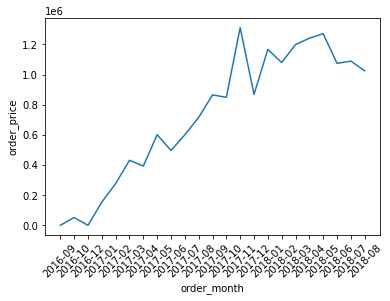

In [97]:
sns.lineplot(data=gmv, x='order_month', y='order_price')
plt.xticks(rotation=45)

In [98]:
gmv['rolling_2'] = gmv['order_price'].rolling(window=2).mean()

# с окном в 2 месяца (окно в один месяц показывает такой же результат, как и исходный)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 <a list of 23 Text major ticklabel objects>)

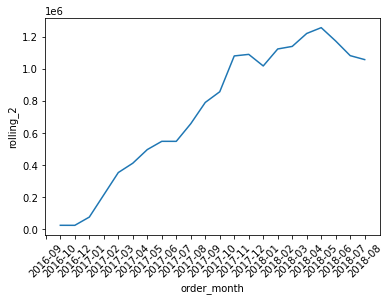

In [99]:
sns.lineplot(data=gmv, x='order_month', y='rolling_2')
plt.xticks(rotation=45)

Анализируя динамику объемов продаж, можно было отметить, как они росли плюс-минус устойчиво до марта 2018 года, но дальше начали сокращаться. Для поддержания роста продаж нам не хватает retention, то есть пользователи не возвращаются в продукт. Наш маркетплейс не обладает PMF, как уже выяснили ранее, не формирует достаточную добавочную ценность для того, чтобы закрывать потребность клиента.

### Объем аудитории, которой продукт доставляет ценность - MAU

Возьмем метрику Monthly Active Users (MAU). Она показывает количество уникальных пользователей, которые совершали операции в маркетплейсе за этот месяц хотя бы один раз.

In [100]:
mau = dff_new.groupby('order_month', as_index=False).customer_unique_id.nunique()

In [101]:
mau

,order_month,customer_unique_id
0,2016-09,1
1,2016-10,262
2,2016-12,1
3,2017-01,718
4,2017-02,1630
5,2017-03,2508
6,2017-04,2274
7,2017-05,3479
8,2017-06,3076
9,2017-07,3802


In [102]:
mau['rolling_2'] = mau.customer_unique_id.rolling(2, min_periods=1).mean()

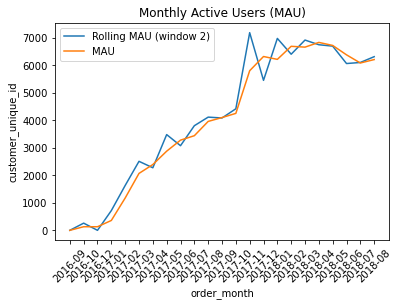

In [103]:
fig = sns.lineplot(data=mau, x='order_month', y='customer_unique_id')
fig = sns.lineplot(data=mau, x='order_month', y='rolling_2')
plt.xticks(rotation=45)
plt.title('Monthly Active Users (MAU)')
plt.legend(labels=['Rolling MAU (window 2)', 'MAU'])

### Метрика, отражающая заинтересованность новых клиентов в продукте

Метрика - конверсия в покупку. С имеющимися данными рассчитать ее не получится, так как нет данных о количестве просматривающих страницу новых пользователях, чтобы рассчитать, какая их доля совершает покупку.

Тем не менее, можно понять, какое количество новых пользователей приходит купить товары каждый месяц.

In [104]:
first_order = dff_new[['customer_unique_id', 'cohort']].groupby('customer_unique_id').cohort.min() \
    .to_frame()\
    .rename(columns={'cohort': 'first_purchase_month'})

first_order

,first_purchase_month
customer_unique_id,
0000366f3b9a7992bf8c76cfdf3221e2,2018-05
0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05
0000f46a3911fa3c0805444483337064,2017-03
0000f6ccb0745a6a4b88665a16c9f078,2017-10
0004aac84e0df4da2b147fca70cf8255,2017-11
...,...
fffcf5a5ff07b0908bd4e2dbc735a684,2017-06
fffea47cd6d3cc0a88bd621562a9d061,2017-12
ffff371b4d645b6ecea244b27531430a,2017-02


In [105]:
first_order.first_purchase_month = first_order.first_purchase_month.astype(str)

In [106]:
new_users = first_order.groupby('first_purchase_month', as_index=True)\
    .agg({'first_purchase_month': 'count'}) \
    .rename(columns={'first_purchase_month': 'new_users'})

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 <a list of 23 Text major ticklabel objects>)

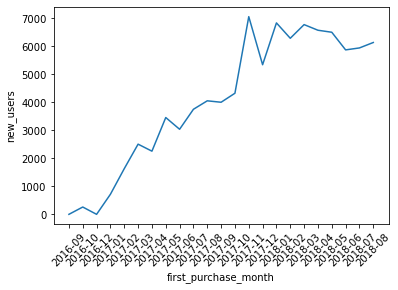

In [107]:
sns.lineplot(data=new_users, x='first_purchase_month', y='new_users')
plt.xticks(rotation=45)

Если посмотреть на результат, то количество новых пользователей каждый месяц почти полностью совпадает с MAU (чуть ниже значения количества новых клиентов, приобретающих товар на маркетплейсе), что логично, если посмотреть на retention, который очень низкий. То есть фактически активную аудиторию составляют постоянно приходящие пользователи, которые долго в продукте не задерживаются.

Но можно сказать, что количество новых клиентов (и активной аудитории) начинает снижаться. Теперь и MAU показывает, что к масштабированию маркетплейс не готов. В какой-то момент компании перестанет хватать денег на привлечение новых пользователей, расходы на привлечение будут больше, чем компания зарабатывает с пользователя. Как раз на примере нашего маркетплейса видна проблема "дырявого ведря". Пользователи приходят и уходят, не находя PMF.

### Метрика, отражающая вовлеченность клиента в продолжение использования продукта

Это и есть метрика retention, которая уже была проанализирована ранее. В задании 2 построен кривая retention и кривая rolling retention.

### Метрика, отражающая денежное выражение вовлеченности клиента

Можно взять метрику Average Revenue per User. Для ее расчета понадобится выручка за месяц.

Показатель будет рассчитан по доставленным заказам (dff_new).

In [108]:
monthly_revenue = dff_new.groupby('order_month').order_price.sum().to_frame()
monthly_revenue

,order_price
order_month,
2016-09,404.91
2016-10,51841.06
2016-12,10.90
2017-01,154511.67
2017-02,277284.99
2017-03,431664.06
2017-04,393642.87
2017-05,601242.82
2017-06,496450.61


In [109]:
total_customer_num = dff_new.groupby('order_month').customer_unique_id.nunique().to_frame() \
    .rename(columns={'customer_unique_id': 'total_number'})

total_customer_num

,total_number
order_month,
2016-09,1
2016-10,262
2016-12,1
2017-01,718
2017-02,1630
2017-03,2508
2017-04,2274
2017-05,3479
2017-06,3076


In [110]:
arpu = monthly_revenue.merge(total_customer_num, on='order_month', how='inner')
arpu['arpu'] = (arpu['order_price'] / arpu['total_number']).round(2)

In [111]:
arpu

,order_price,total_number,arpu
order_month,,,
2016-09,404.91,1,404.91
2016-10,51841.06,262,197.87
2016-12,10.90,1,10.90
2017-01,154511.67,718,215.20
2017-02,277284.99,1630,170.11
2017-03,431664.06,2508,172.11
2017-04,393642.87,2274,173.11
2017-05,601242.82,3479,172.82
2017-06,496450.61,3076,161.39


In [112]:
arpu['rolling_3'] = arpu.arpu.rolling(3, min_periods=1).mean()

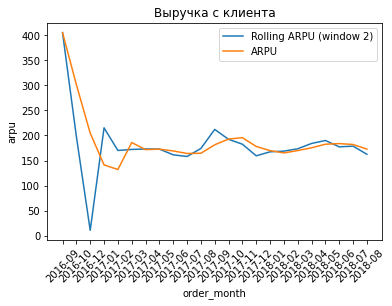

In [113]:
fig = sns.lineplot(data=arpu, x='order_month', y='arpu')
fig = sns.lineplot(data=arpu, x='order_month', y='rolling_3') 
# здесь сделаем окно больше, чтобы посмотреть динамику
plt.xticks(rotation=45)
plt.title('Выручка с клиента')
plt.legend(labels=['Rolling ARPU (window 2)', 'ARPU'])

Выручка с пользователя стабилизровалась на плато, но можно рассмотреть тенденцию к снижению с апреля 2018 года. Клиенты не стремятся повысить свои расходы на нашем маркетплейсе.

## Задача 4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.

In [114]:
dff_corr = dff_all.query("cohort>='2017-06'")

In [115]:
retention = retention_matrix[1].median() * 100
retention

0.3658342611738508

Гипотеза 1: Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

Баг в системе прессинга - это ошибка, которая вызывает ложные отмены заказов. Смотрим среди unavailable и canceled статусов. Возможные ситуации, которые надо рассмотреть:
- Платеж не одобрен (переменная approved), хотя клиент осуществил платеж, деньги списались. В результате заказ был отменен. Надо посмотреть, когда нет данных в столбце order_approved_at.
- Ситуации, когда товара на самом деле нет, информации никакой о нем нет (о цене), но по какой-то причине система позволяет пользователю его купить, одобряет платеж, но потом отменяет заказ по причине его отсутствия (unavailiable).
- Заказы, которые были отменены из-за сбоя в расчете сроков доставки (колонка order_delivered_carrier_date).

In [116]:
case_1 = dff_corr.query("order_status == 'canceled' or order_status == 'unavailable'") \
    .loc[dff_corr.order_approved_at.isna()]

case_1
# такие заказы только со статусом canceled

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,cohort,cohort_day,period_number_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_price
1203,1d07a80a15700b40cb15ff5870ee8b48,0e9bafe047d5c6fe3fd8ef6bcdce9a1a,62030,sobral,CE,85e05c3c9aa9834518f35d4f286014be,canceled,2018-08-28 08:18:22,NaT,NaT,...,2018-08,2018-08-28,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0
1218,ad2eb5d02c0808bcd8743117f6383cf6,ef0103e9602d12594d19c2b666219bc1,30810,belo horizonte,MG,bd35b677fd239386e9861d11ae98ab56,canceled,2018-09-17 17:21:16,NaT,NaT,...,2018-08,2018-08-29,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0
1867,82d98198f7fb1687858e03a5322e1621,b351ac91ab0ef29bae6da7fbc05959c0,80420,curitiba,PR,38a86eb53c2309d6234fc9bad96331ac,canceled,2018-08-18 12:39:31,NaT,NaT,...,2018-08,2018-08-18,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0
3657,b1253701171dfb298f52a221f824e45b,788313d21c3507fe890921f6e17aa679,11070,santos,SP,afed0d88ec7753e7be8744bb66e860d1,canceled,2018-08-02 15:23:07,NaT,NaT,...,2018-03,2018-03-07,4.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0
4278,a73c1f73f5772cf801434bf984b0b1a7,968fac81e2c44fb6c1e3ac2a45e6a102,4685,sao paulo,SP,4637ca194b6387e2d538dc89b124b0ee,canceled,2018-09-03 14:14:25,NaT,NaT,...,2018-09,2018-09-03,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106546,d6441eef3f37c3edb0d5634c3c85120b,ef0103e9602d12594d19c2b666219bc1,30810,belo horizonte,MG,1ad22e16129698e1a3cc11e4350d2cb7,canceled,2018-09-12 15:32:16,NaT,NaT,...,2018-08,2018-08-29,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0
106893,936da706de2dfa07d2f5f8e3934836ca,cce3432f546c60893bd2ad7a2001148a,31910,belo horizonte,MG,ec88cd13421e27489ffc1f352247f3a4,canceled,2018-08-24 16:38:44,NaT,NaT,...,2018-08,2018-08-04,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0
108895,8e9e28f565a0e470a97fd879909388fe,d9456ef6d4231fb2637e490212b3e32f,18055,sorocaba,SP,596288a27579ad1fec1d704efe7d9ab7,canceled,2017-08-30 18:48:01,NaT,NaT,...,2017-08,2017-08-30,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0
108969,719ed1620e6d57e729521a5408f6e9dd,d35b852498996bd67a141c266e92f35b,1042,sao paulo,SP,66e4a36ff490014773971a6ee0b6a0e4,canceled,2017-06-20 12:39:25,NaT,NaT,...,2017-06,2017-06-20,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0


In [117]:
case_2 = dff_corr.query("order_status == 'unavailable'").loc[dff_corr.price.isna()]

case_2

# здесь не рассматриваем ситуации отмененных заказов

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,cohort,cohort_day,period_number_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_price
422,b08064e24083fee8fbe8797902b07ecd,035f60af6e7d7f78470e9443be08d339,28495,aperibe,RJ,c609f82bcf7a90292a5940205ebd7e93,unavailable,2018-05-13 16:45:55,2018-05-13 17:11:58,NaT,...,2018-05,2018-05-13,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0
432,536f46cc0f2f2b1e40d056f7998f0254,340152332a04149987a705602615f0d0,87030,maringa,PR,cb4a79c1e6c9ae44302861e7602cc449,unavailable,2017-12-06 15:46:07,2017-12-06 15:57:29,NaT,...,2017-12,2017-12-06,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0
627,8118922685d2e2c0205f060be4f2579c,d0e87d00021530383c16452a39a393ba,45810,porto seguro,BA,af264f3527e94e431f0dcd56cd6b406d,unavailable,2017-07-12 14:49:11,2017-07-12 15:04:10,NaT,...,2017-07,2017-07-12,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0
638,6e067aaac313f893bd40273d8d75027f,f9ac86b4993a6e2a48758cb47d808712,89150,presidente getulio,SC,31f935babbc97f5990e0ffd128e19541,unavailable,2017-11-11 11:25:27,2017-11-11 11:35:31,NaT,...,2017-11,2017-11-11,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0
675,b8be9aabc886bf52d9361784b379ea49,7649b15c0f9e10a06fd969de050553bf,28893,rio das ostras,RJ,08ee9c1b1da47ffd2a7c7163aa134b16,unavailable,2017-08-04 21:47:44,2017-08-04 22:04:51,NaT,...,2017-08,2017-08-04,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111760,c13b88bfce55305a9240404088bd6a46,d6bc315c133be9c0a334b96002b4c1c1,13060,campinas,SP,f87f3a5e91df877dc36b65fb69ff2465,unavailable,2018-07-30 21:49:41,2018-07-30 22:24:21,NaT,...,2018-07,2018-07-30,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0
112085,7353b0fb8e8d9675e3a704c60ca44ebe,21c933c8dd97d088e64c50988c90ccf5,5017,sao paulo,SP,2f634e2cebf8c0283e7ef0989f77d217,unavailable,2017-09-27 20:55:33,2017-09-28 01:32:50,NaT,...,2017-09,2017-09-27,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0
112143,5effe9491d0f5a1c12ee4a384ec09bdf,e9429d622d9e764ca60ba01bc252b0a8,8690,suzano,SP,2b0edc4c59d83dcef85466718c36a317,unavailable,2017-09-29 19:17:10,2017-09-29 20:00:07,NaT,...,2017-09,2017-09-29,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0
112517,1761db2f0d235bbfa1c281093198af0c,21c2c79d24e2d8e3496aabb1f65d85c6,20270,rio de janeiro,RJ,8b08f0e729f58529ed03e763270f78d5,unavailable,2017-08-24 21:02:47,2017-08-24 21:15:36,NaT,...,2017-08,2017-08-24,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0


In [118]:
case_3 = dff_corr.query("order_status == 'canceled'") \
    .loc[dff_corr.order_approved_at.notna()] \
    .loc[dff_corr.order_delivered_carrier_date.isna()]

# заказы, которые были отменены из-за сбоя в расчете сроков доставки

In [119]:
cases = pd.concat([case_1, case_2, case_3])

In [120]:
impact_hypothesis_1 = cases.order_id.nunique()

In [121]:
# теперь смотрим ситуацию дублирования заказа, но с разным статусом

cancelled_orders = dff_corr.query("order_status == 'canceled' or order_status == 'unavailable'")['customer_unique_id']

In [122]:
dff_corr.query("order_status != 'unavailable' and order_status != 'canceled'")\
    .query('customer_unique_id in @cancelled_orders')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,cohort,cohort_day,period_number_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_price
2442,d58d04003ac810adac58890472e3a443,788313d21c3507fe890921f6e17aa679,11070,santos,SP,0ec21892fbe1319a9e0363cab0066fb0,delivered,2018-03-07 16:02:00,2018-03-07 16:15:38,2018-03-09 16:16:27,...,2018-03,2018-03-07,0.0,1.0,d285360f29ac7fd97640bf0baef03de0,4869f7a5dfa277a7dca6462dcf3b52b2,2018-03-13 16:15:38,329.0,14.74,329.0
3856,645afc7ee52104e787757012bc532832,320e13a9e22b4e4cda8c17ed1c140ce0,13660,porto ferreira,SP,afbe0c76e58378669c3924e11182b02c,delivered,2017-12-05 22:17:41,2017-12-07 22:16:34,2017-12-13 16:43:10,...,2017-11,2017-11-27,0.0,1.0,7be620cd314ce6460033ba9017be7a7f,7aa4334be125fcdd2ba64b3180029f14,2017-12-13 22:16:34,41.8,13.37,41.8
3876,3cb9c099a7c6bc5ce1d4e1f8e2ea6644,76c97e01b5a2a58b8456c4db49bd988b,37478,soledade de minas,MG,f4f8aa5fb2ceaeb486500d9a7926a272,delivered,2018-02-22 16:06:15,2018-02-24 02:55:35,2018-02-26 20:56:50,...,2018-02,2018-02-22,0.0,1.0,5373e18844eec682770d139ba29cd32c,efcd8d2104f1a05d028af7bad20d974b,2018-03-01 02:55:35,50.0,15.10,50.0
3992,209e7cf8adaf4498f82df1fe2b8c25e7,91544d22848a922381b73b5e21ad58ff,8072,sao paulo,SP,57a7b18332c1b9b26d96e35379af3a38,shipped,2018-08-06 19:25:14,2018-08-08 04:35:15,2018-08-17 14:32:00,...,2018-08,2018-08-06,0.0,1.0,b73091f98b819cf7a339f74ece86aa4b,a6fe7de3d16f6149ffe280349a8535a0,2018-08-16 04:35:15,59.9,13.08,59.9
5149,0af2831dd8e096d67a27ba7cfba20f78,e61f0f032bc92cadf0ec55f9c1c8b5ec,13848,mogi-guacu,SP,9b8ac5a3f09f1af11380aa4451dc2ac4,delivered,2018-08-08 15:40:33,2018-08-08 15:55:14,2018-08-09 05:57:00,...,2018-08,2018-08-08,0.0,1.0,c85ef665dddff9ed38e6545814f24a0d,6824a69c9ea0313eba299dd4a2dba09a,2018-08-14 15:55:14,186.4,20.48,186.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111965,6e4fce89806ba59751307949337ed655,42befda568ea0df110b6cec63c233bea,2801,sao paulo,SP,50cbc0ce14ba62ab76c2c353dbf6bb7d,delivered,2017-10-09 12:17:50,2017-10-09 12:49:15,2017-10-10 19:43:49,...,2017-10,2017-10-09,0.0,1.0,f5f0e64686adaf487590fbb8a75a1d2c,c3867b4666c7d76867627c2f7fb22e21,2017-10-17 13:49:15,193.0,16.98,193.0
112450,7002324a84090313fb63b8d372fca9a6,2844216d0982f6ced6f8cb8c2ede4136,93800,sapiranga,RS,118ec9ddef528c64a545169b898e7699,delivered,2017-07-04 18:51:25,2017-07-05 19:23:13,2017-07-06 15:41:24,...,2017-07,2017-07-04,0.0,1.0,3a64d31450c3b7d6451627e5fad88d77,abc015ebac1d283a323ca9db35ede4b9,2017-07-11 19:03:07,10.9,15.10,10.9
112627,3384115feb88ac6ec6294086d0345836,683cda1913456fb0cca302892b37a052,3978,sao paulo,SP,304137040eac6e7582eb945e3f347120,processing,2018-01-05 12:18:07,2018-01-05 12:27:46,NaT,...,2017-12,2017-12-19,0.0,1.0,0a57f7d2c983bcf8188589a5fea4a8da,4342d4b2ba6b161468c63a7e7cfce593,2018-01-17 12:27:46,129.9,14.66,129.9
113183,0e240f6e253b7d7646700ce3b28fe413,6d443b75cff956bb73dce7385033e266,13215,jundiai,SP,a1fa82769a203e30b8faf81cd32e5193,delivered,2017-09-05 09:29:17,2017-09-06 19:43:28,2017-09-08 21:57:42,...,2017-08,2017-08-31,0.0,1.0,4754d89182db4010eabbf20da5fb7191,8e6cc767478edae941d9bd9eb778d77a,2017-09-13 19:43:28,145.9,90.10,350.9


In [123]:
print(f"Impact гипотезы 1: на {impact_hypothesis_1} увеличится количество доставленных заказов")

Impact гипотезы 1: на 898 увеличится количество доставленных заказов


In [124]:
impact_score_hypothesis_1 = 4

In [125]:
ice_hypothesis_1 = impact_score_hypothesis_1 * 8 * 6
ice_hypothesis_1

192

Гипотеза 2: Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов. 

Отгрузка заказа включает в себя процессы доставки до покупателя продукта.  Поэтому здесь посмотрим, где были задержки и заказ пришел позже планируемой даты. И эти условия повлияли на то, что клиент не вернулся совершить повторную покупку.

Ожидаемый результат - ээто изменение в количестве заказов.

In [126]:
dff_all['order_purchase_timestamp'] = pd.to_datetime(dff_all['order_purchase_timestamp'])

In [127]:
# добавим столбец с датой последнего заказа

dff_all['last_purchase_day'] = dff_all.groupby('customer_unique_id')['order_purchase_timestamp'] \
    .transform('max').dt.to_period('D')

In [128]:
dff_corr = dff_all.query("cohort >= '2017-06'") 
# опять наложим фильтр на время

In [129]:
impact_hypothesis_2 = dff_corr.query("order_status == 'delivered'")\
    .query("order_estimated_delivery_date < order_delivered_customer_date") \
    .query("order_purchase_timestamp.dt.to_period('D') == last_purchase_day").order_id.nunique()

# фильтрация по тем людям, у которых заказ прибыл позже планируемого и стал их последним 
# но при этом статус у заказа "доставлен"

In [130]:
print(f"Impact гипотезы 2: на {impact_hypothesis_2} увеличится количество заказов")

Impact гипотезы 2: на 7141 увеличится количество заказов


In [131]:
impact_score_2 = 8

In [132]:
ice_hypothesis_2 = impact_score_2 * 10 * 4
ice_hypothesis_2

320

Гипотеза 3: Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.

- Рассмотрим следующие возможные случаи:
    - Оплата не прошла (Nan в столбце order_approved_at) и пользователи больше не делали заказ
    - Обработка оплаты занимает слишком долгое время (рассмотрим случаи, когда она занимает 7 дней и больше).

In [133]:
dff_corr.loc[dff_corr.order_approved_at.isna()].query('order_status == "canceled"')


# те, у кого не прошла оплата
# 5 ситуаций, когда заказ был создан, тут еще не может анализировать поведение клиента
# во всех остальных случаях заказ был отменен, поэтому сразу сделаем фильтр по canceled

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,cohort_day,period_number_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_price,last_purchase_day
1203,1d07a80a15700b40cb15ff5870ee8b48,0e9bafe047d5c6fe3fd8ef6bcdce9a1a,62030,sobral,CE,85e05c3c9aa9834518f35d4f286014be,canceled,2018-08-28 08:18:22,NaT,NaT,...,2018-08-28,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0,2018-08-28
1218,ad2eb5d02c0808bcd8743117f6383cf6,ef0103e9602d12594d19c2b666219bc1,30810,belo horizonte,MG,bd35b677fd239386e9861d11ae98ab56,canceled,2018-09-17 17:21:16,NaT,NaT,...,2018-08-29,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0,2018-09-17
1867,82d98198f7fb1687858e03a5322e1621,b351ac91ab0ef29bae6da7fbc05959c0,80420,curitiba,PR,38a86eb53c2309d6234fc9bad96331ac,canceled,2018-08-18 12:39:31,NaT,NaT,...,2018-08-18,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0,2018-08-18
3657,b1253701171dfb298f52a221f824e45b,788313d21c3507fe890921f6e17aa679,11070,santos,SP,afed0d88ec7753e7be8744bb66e860d1,canceled,2018-08-02 15:23:07,NaT,NaT,...,2018-03-07,4.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0,2018-08-02
4278,a73c1f73f5772cf801434bf984b0b1a7,968fac81e2c44fb6c1e3ac2a45e6a102,4685,sao paulo,SP,4637ca194b6387e2d538dc89b124b0ee,canceled,2018-09-03 14:14:25,NaT,NaT,...,2018-09-03,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0,2018-09-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106546,d6441eef3f37c3edb0d5634c3c85120b,ef0103e9602d12594d19c2b666219bc1,30810,belo horizonte,MG,1ad22e16129698e1a3cc11e4350d2cb7,canceled,2018-09-12 15:32:16,NaT,NaT,...,2018-08-29,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0,2018-09-17
106893,936da706de2dfa07d2f5f8e3934836ca,cce3432f546c60893bd2ad7a2001148a,31910,belo horizonte,MG,ec88cd13421e27489ffc1f352247f3a4,canceled,2018-08-24 16:38:44,NaT,NaT,...,2018-08-04,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0,2018-08-24
108895,8e9e28f565a0e470a97fd879909388fe,d9456ef6d4231fb2637e490212b3e32f,18055,sorocaba,SP,596288a27579ad1fec1d704efe7d9ab7,canceled,2017-08-30 18:48:01,NaT,NaT,...,2017-08-30,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0,2017-08-30
108969,719ed1620e6d57e729521a5408f6e9dd,d35b852498996bd67a141c266e92f35b,1042,sao paulo,SP,66e4a36ff490014773971a6ee0b6a0e4,canceled,2017-06-20 12:39:25,NaT,NaT,...,2017-06-20,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0,2017-06-20


In [134]:
case_1 = dff_corr.loc[dff_corr.order_approved_at.isna()].query('order_status == "canceled"')\
    .query("order_purchase_timestamp.dt.to_period('D') == last_purchase_day")

case_1
# добавили условие, что покупка стала последней для пользователей

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,cohort_day,period_number_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_price,last_purchase_day
1203,1d07a80a15700b40cb15ff5870ee8b48,0e9bafe047d5c6fe3fd8ef6bcdce9a1a,62030,sobral,CE,85e05c3c9aa9834518f35d4f286014be,canceled,2018-08-28 08:18:22,NaT,NaT,...,2018-08-28,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0,2018-08-28
1218,ad2eb5d02c0808bcd8743117f6383cf6,ef0103e9602d12594d19c2b666219bc1,30810,belo horizonte,MG,bd35b677fd239386e9861d11ae98ab56,canceled,2018-09-17 17:21:16,NaT,NaT,...,2018-08-29,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0,2018-09-17
1867,82d98198f7fb1687858e03a5322e1621,b351ac91ab0ef29bae6da7fbc05959c0,80420,curitiba,PR,38a86eb53c2309d6234fc9bad96331ac,canceled,2018-08-18 12:39:31,NaT,NaT,...,2018-08-18,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0,2018-08-18
3657,b1253701171dfb298f52a221f824e45b,788313d21c3507fe890921f6e17aa679,11070,santos,SP,afed0d88ec7753e7be8744bb66e860d1,canceled,2018-08-02 15:23:07,NaT,NaT,...,2018-03-07,4.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0,2018-08-02
4278,a73c1f73f5772cf801434bf984b0b1a7,968fac81e2c44fb6c1e3ac2a45e6a102,4685,sao paulo,SP,4637ca194b6387e2d538dc89b124b0ee,canceled,2018-09-03 14:14:25,NaT,NaT,...,2018-09-03,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0,2018-09-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102202,92af427e290117f39d9ff908566072e0,e61f0f032bc92cadf0ec55f9c1c8b5ec,13848,mogi-guacu,SP,5290c34bd38a8a095b885f13958db1e1,canceled,2018-08-21 10:25:18,NaT,NaT,...,2018-08-08,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0,2018-08-21
106445,0b0d6095c5555fe083844281f6b093bb,e90598185d2427a35e32ef241a5c04aa,11075,santos,SP,3a3cddda5a7c27851bd96c3313412840,canceled,2018-08-31 16:13:44,NaT,NaT,...,2018-08-31,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0,2018-08-31
106893,936da706de2dfa07d2f5f8e3934836ca,cce3432f546c60893bd2ad7a2001148a,31910,belo horizonte,MG,ec88cd13421e27489ffc1f352247f3a4,canceled,2018-08-24 16:38:44,NaT,NaT,...,2018-08-04,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0,2018-08-24
108895,8e9e28f565a0e470a97fd879909388fe,d9456ef6d4231fb2637e490212b3e32f,18055,sorocaba,SP,596288a27579ad1fec1d704efe7d9ab7,canceled,2017-08-30 18:48:01,NaT,NaT,...,2017-08-30,0.0,NaN,NaN,NaN,NaT,NaN,NaN,0.0,2017-08-30


In [135]:
# посмотрим случаи, когда оплата обрабатывалась очень долго и клиенты больше не сделали заказ
# это тоже можно рассматривать, как проблемы с оплатой

dff_corr_copy = dff_corr.copy()

In [136]:
dff_corr_copy['payment_processing'] = dff_corr_copy.order_approved_at - dff_corr_copy.order_purchase_timestamp

In [137]:
dff_corr_copy['payment_processing_days'] = dff_corr_copy['payment_processing'].dt.components['days']

# рассчитаем количество дней, которые оплата обрабатывалась

In [138]:
case_2 = dff_corr_copy[dff_corr_copy['payment_processing_days'] >= 7]\
    .query("order_purchase_timestamp.dt.to_period('D') == last_purchase_day")\
    .query("order_estimated_delivery_date >= order_delivered_customer_date")

# предположим, что проблемой будем считать случаи, когда больше 7 дней обработка оплаты
# исключаем случаи, когда доставка все равно пришла вовремя
# таким образом, исключаем ситуации, когда произошла задержка в доставке и клиенты не вернулись именно по этой причине

In [139]:
case_3 = dff_corr_copy[dff_corr_copy['payment_processing_days'] >= 15]\
    .query("order_purchase_timestamp.dt.to_period('D') == last_purchase_day")


# критические случаи, когда оплата не проходила больше 15 дней
# в таких случаях доставка приходила всегда с задержкой

In [140]:
cases = pd.concat([case_1, case_2, case_3])

In [141]:
impact_hypothesis_3 = cases.order_id.nunique()

In [142]:
print(f"Impact гипотезы 3: на {impact_hypothesis_3} увеличится количество заказов")

Impact гипотезы 3: на 150 увеличится количество заказов


In [143]:
ice_hypothesis_3 = 3 * 5 * 9
ice_hypothesis_3

135

Вывод:

- Наибольший ICE-score у гипотезы 2: 320.
- Предполагаем, что на 7141 увеличится количество заказов, если сократить время отгрузки заказа.


Вторая по приоритетности: гипотеза 1. ICE score равен 192.

Третья по приоритетности: гипотеза 3. ICE score равен 135.

## Задача 5. Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.

Выбранная гипотеза:
    
- Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов. 

Целевые метрики:

1. Repeat Purchase rate 

Метрика, показывающая, какой процент покупателей совершает повторные покупки за определенный период времени, от общего количество покупателей в этот период. Ее легко посчитать, она чувствительна к изменениям, интерпретируема, так как мы хотим увеличить количество повторных заказов и возвращаемость клиента в продукт (retention). Если доля таких покупателей растет, то это говорит о том, все большая доля клиентов становится более заинтересованной в продукте, они удовлетворены качеством услуг и остаются в продукте. 

2. Доля вовремя доставленных заказов

Показывает, что мера по сокращению времени отгрузки эффективна, так как приводит к тому, что большая доля заказов теперь приходит вовремя. Данную метрику можно рассчитать, она чувствительна. Нельзя повлиять на нее какими-то другими факторами. Но ее можно измерить только по окончанию эксперимента.

3. Среднее время до отгрузки

Гипотеза напрямую воздействует на время отгрузки заказа. Метрика будет показывать, получается ли сократить это время. Поэтому метрика интерпретируема. Соблюдаются требования чувствительности и достоверности. Но получить результат также можно только по окончанию эксперимента.

Proxy-метрики:

Так как описанные выше целевые метрики можно рассчитать только по итогам определенного периода, чтобы сформировать примерное представление об эффективности гипотезы, можно рассчитать следующие метрики:

1. AOV - средняя сумма заказа или ARPU - средний чек пользователя

Если значение метрик возрастает, это показывает, что вовлеченность клиента в продукт возрастает. Он покупает больше, что говорит о том, что его удовлетворенность продуктом и уверенность в предоставляемых услугах (скорости доставки в том числе) растет. Эту метрику можно оценить заранее, понять, действенно ли то, что мы делаем. Когда мы знаем, что заказ нигде не потеряется, придет вовремя, то готовы заказать больше товаров (риски становятся ниже).

2. Доля повторных заказов среди поступивших заказов 

Метрика показывает, сколько клиентов возвращается, чтобы сделать повторный заказ. Метрику легко рассчитать, она интерпретируема: напрямую воздействует на retention rate. Если доля таких заказов возрасла, то значит клиенты стали охотнее заказывать повторно, retention rate будет возрастать.

Варианты guardrail метрики:

1. Коэффициент ошибок при отгрузках

Метрика показывает отношение количества заказов, отпущенных со склада с ошибками к общему количеству обработанных заказов. По причине сокращения времени отгрузки, в спешке при отгрузке продавцы могут совершать ошибки, например, при заполнении сопроводительной документации, маркировке, транспортировке товаров. Из-за ошибок маркетплейс не может принять товар, отгрузка аннулируется. Соответственно, ожидание заказа увеличивается, может увеличить количество отказов от товара.

2. Коэффициент ошибок при комплектации (/некачественной работы комплектовщиков)

Если сокращаем время до отгрузки, то может совершаться большее количество ошибок при комплектации заказов. Это может ухудшать пользовательский опыт клиента и, наоборот, снижать их желание повторно использовать услуги.

3. Операционные затраты (COGS) -> затраты на одного клиента

Попытки перейти на более быструю отгрузку могут привести к повышению затрат на перевозку заказов (одного заказа). Это влияет на LTV, снижает выручку на одного клиента. Таким образом, есть риск того, что юнит-экономика не будет сходить.


## Задача 6. Выводы и рекомендации

Выводы по итогам работы:
1. Когортный анализ показал очень низкий retention по всем когортам, показатели приближены к 0. 
    - Медианный retention 1-го месяца для всех когорт составляет 0.3658%.
    - Самый высокий retention 3-го месяца у когорты 2017-01 - 0.5571%.
2. У продукта отсутствует Product/market fit:
    - Продукт не создает достаточной добавочной ценности для клиента
    - Клиенты приходят в первый месяц и не задерживаются в продукте: медианны retention последующих месяцев, кроме первого, стремится к 0%. Retention вышел на плато, но сильно близко к 0.
    - На данный момент продукт не готов к масштабированию.
3. Возможные причины, которые мешают в достижении PMF: 
    - Задержки в доставке заказа (позже планируемого срока):
        - Доля опоздавших заказов среди доставленных составляет 6.57%
        - Доля опоздавших заказов, которые все еще в пути (или обрабатываются): 2.36%.
        - В общей сложности больше 8% заказов не были доставлены в запланированный срок.
    - Половина заказов не была доставлена в планируемый срок до логистической службы.
    - Проблемы с оплатой заказов, долгое ожидание обработки оплаты.
4. Метрики, на которых стоит сконцентрироваться для максимизации прибыли:
    - Отражает рост объёма продаж маркетплейса - Gross Merchandise Value (GMV).
    - Показывает объем аудитории, которой продукт доставляет ценность, - Monthly Active Users (MAU).
    - Отражает заинтересованность новых клиентов в продукте - Конверсия в покупку, количество новых клиентов в месяц (оценили).
    - Отражает вовлеченность клиента в продолжение использования продукта - Retention.
    - Отражает денежное выражение вовлеченности клиента - Average Revenue per User (ARPU).
    
Общий вывод: активные клиенты почти все из числа новых пользователей, которые приходят каждый месяц, так как старые пользователи в продукте не задерживаются. Средний доход в расчете на пользователя и объем продаж Gross Merchandise Value вышли на плато и начинают сокращаться, не хватает клиентов, они не вовлечены в покупки. В таких условиях нельзя масшабироваться, расходы в какой-то момент превысят доходы, и мы уйдем в убыток. Если бы можно было оценить LTV (расходы на клиентов, о которых нет данных), можно было бы сделать вывод о том, сходится ли юнит-экономика. Но есть подозрения, что нет.

5. В результате расчета ICE-score для трех наших гипотез был сделан вывод, что приоритетной является вторая гипотеза:

- Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов.

6. Метрики, на которые повлияет гипотеза:
- Целевые метрики: Repeat Purchase rate, доля вовремя доставленных заказов, среднее время до отгрузки.
- Proxy-метрики: ARPU, AOV, доля повторных заказов среди поступивших заказов.
- Guardrail метрики: коэффициент ошибок при отгрузках, коэффициент ошибок при комплектации (/некачественной работы комплектовщиков), операционные затраты (COGS).

Рекомендации:
1. Ускорить процесс обработки оплаты заказа, так как в некоторых случаях они занимают больше 20 дней. Это также влияет на появление задержек в доставке заказа, приводит к отменам заказов.
2. Посмотреть, сталкиваются ли с проблемами при осуществлении заказов клиенты из других штатов Бразилии, кроме Сан-Пауло. По какой причине идет явное смещение в сторону данного штата. Возможно, есть проблемы в системе именно у жителей других штатов/городов.
3. Проанализировать данные о просмотрах сайта, времени, проведенном на сайте и другие показатели, которые характеризуют опыт взаимодействия клиента с сайтом маркетпелйса еще до совершения заказа, чего по имеющимся данным мы сделать пока не смогли. 
4. Проанализировать способы привлечения клиентов, сформулировать более сегментированный подход к удержанию старых клиентов, чтобы повысить retention.